In [13]:
# Import Required Libraries
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime
import urllib.parse
from collections import Counter
import openpyxl  # For Excel export

## Configuration
Set up API key and load all TomTom categories

In [ ]:
# TomTom API Configuration
API_KEY = "d5TWC3g2TRMlQr6VQvk0h5pfdQGrqCtA"
PLACES_API_URL = "https://api.tomtom.com/search/2/nearbySearch/.json"

print("✓ Configuration loaded")
print(f"  API Key: {API_KEY[:10]}...")

✓ Configuration loaded
  API Key: ytvMXyUN62...


## Load All TomTom Categories
Load all category codes from Excel file - we'll use them directly without simplification

In [15]:
def load_all_tomtom_categories():
    """
    Load all TomTom category codes from Excel file
    Returns a list of all valid category codes
    """
    try:
        # Read from Excel file
        df = pd.read_excel('tom_tom_categories.xlsx')
        
        # Get the category codes from the first column
        category_column = df.columns[0]
        
        # Extract all category codes (non-empty rows)
        category_codes = df[category_column].dropna().tolist()
        
        # Clean and filter codes
        all_categories = []
        for code in category_codes:
            code_str = str(code).strip()
            if code_str and code_str != 'Category code':
                all_categories.append(code_str)
        
        print(f"✓ Loaded {len(all_categories)} TomTom category codes from Excel")
        
        # Show first 20 categories as examples
        print(f"\n📋 First 20 categories:")
        for i, cat in enumerate(all_categories[:20], 1):
            print(f"  {i:2d}. {cat}")
        
        return all_categories
        
    except FileNotFoundError:
        print("⚠️  tom_tom_categories.xlsx not found")
        print("   Using minimal fallback categories...")
        # Minimal fallback if file not found
        return [
            'RESTAURANT', 'CAFE_PUB', 'HOTEL_MOTEL', 'COMPANY', 'SHOP',
            'SHOPPING_MALL', 'HOSPITAL_POLYCLINIC', 'SCHOOL', 'COLLEGE_UNIVERSITY',
            'CINEMA', 'AIRPORT', 'PUBLIC_TRANSPORT_STOP', 'PARKING_GARAGE',
            'PETROL_STATION', 'BANK', 'PLACE_OF_WORSHIP', 'SPORTS_CENTER',
            'PARK_RECREATION_AREA', 'GOVERNMENT_OFFICE', 'RESIDENTIAL_ACCOMMODATION',
            'INDUSTRIAL_BUILDING', 'AUTOMOTIVE_DEALER'
        ]
    except Exception as e:
        print(f"⚠️  Error reading Excel file: {str(e)}")
        print("   Using minimal fallback categories...")
        return []

# Load all TomTom categories
ALL_TOMTOM_CATEGORIES = load_all_tomtom_categories()

print(f"\n✓ Total categories to track: {len(ALL_TOMTOM_CATEGORIES)}")

✓ Loaded 107 TomTom category codes from Excel

📋 First 20 categories:
   1. ACCESS_GATEWAY
   2. ADMINISTRATIVE_DIVISION
   3. ADVENTURE_SPORTS_VENUE
   4. AGRICULTURE
   5. AIRPORT
   6. AMUSEMENT_PARK
   7. AUTOMOTIVE_DEALER
   8. BANK
   9. BEACH
  10. BUILDING_POINT
  11. BUSINESS_PARK
  12. CAFE_PUB
  13. CAMPING_GROUND
  14. CAR_WASH
  15. CASH_DISPENSER
  16. CASINO
  17. CINEMA
  18. CITY_CENTER
  19. CLUB_ASSOCIATION
  20. COLLEGE_UNIVERSITY

✓ Total categories to track: 107


## Load Locations Data
Load the 100 locations with coordinates from CSV

In [16]:
# Load locations from CSV
locations_df = pd.read_csv('100_locations_with_coords.csv')

# Display basic info
print(f"✓ Loaded {len(locations_df)} locations")
print(f"\nColumns: {list(locations_df.columns)}")
print(f"\nFirst 5 locations:")
print(locations_df.head())

# Check for missing coordinates
missing_coords = locations_df[locations_df['latitude'].isna() | locations_df['longitude'].isna()]
print(f"\n⚠️  Locations with missing coordinates: {len(missing_coords)}")
if len(missing_coords) > 0:
    print(missing_coords[['location_name']])

✓ Loaded 150 locations

Columns: ['location_name', 'latitude', 'longitude']

First 5 locations:
                         location_name   latitude  longitude
0  Mumbai Central, Mumbai, Maharashtra  18.977037  72.826266
1          CG Road, Ahmedabad, Gujarat  23.108360  72.586911
2               MG Road, Kochi, Kerala  10.516033  76.253846
3  Banjara Hills, Hyderabad, Telangana  17.409104  78.439467
4        Vastrapur, Ahmedabad, Gujarat  23.035083  72.527644

⚠️  Locations with missing coordinates: 0


## Fetch Nearby Places Function
Get nearby POIs from TomTom Places API for a given location

In [17]:
def get_nearby_places(lat, lon, radius=1000, limit=100):
    """
    Fetch nearby places from TomTom Places API
    
    Args:
        lat: Latitude
        lon: Longitude
        radius: Search radius in meters (default 1000m = 1km)
        limit: Maximum number of results (default 100)
    
    Returns:
        JSON response from API or None if error
    """
    params = {
        'lat': lat,
        'lon': lon,
        'key': API_KEY,
        'radius': radius,
        'limit': limit
    }
    
    try:
        response = requests.get(PLACES_API_URL, params=params)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"  ✗ API Error: {str(e)}")
        return None
    except Exception as e:
        print(f"  ✗ Unexpected Error: {str(e)}")
        return None

# Test with first location
if len(locations_df) > 0:
    test_loc = locations_df.iloc[0]
    print(f"Testing API with: {test_loc['location_name']}")
    print(f"Coordinates: ({test_loc['latitude']}, {test_loc['longitude']})")
    
    test_result = get_nearby_places(test_loc['latitude'], test_loc['longitude'], limit=10)
    
    if test_result:
        print(f"\n✓ API Test Successful!")
        print(f"  Total results available: {test_result['summary']['totalResults']}")
        print(f"  Results returned: {test_result['summary']['numResults']}")
        
        if len(test_result['results']) > 0:
            first_poi = test_result['results'][0]
            print(f"\n  Example POI:")
            print(f"    Name: {first_poi['poi']['name']}")
            print(f"    Categories: {first_poi['poi'].get('categories', [])}")
            if 'classifications' in first_poi['poi']:
                print(f"    Classifications: {[c['code'] for c in first_poi['poi']['classifications']]}")

Testing API with: Mumbai Central, Mumbai, Maharashtra
Coordinates: (18.9770366, 72.826266)

✓ API Test Successful!
  Total results available: 100
  Results returned: 10

  Example POI:
    Name: I-Square Automobiles
    Categories: ['automotive dealer', 'motorcycle']
    Classifications: ['AUTOMOTIVE_DEALER']


## Extract and Count All Categories
Extract classifications from API response and count all TomTom categories directly

In [18]:
def extract_categories_from_response(api_response):
    """
    Extract and count ALL TomTom categories from API response
    No simplification - use raw category codes directly
    
    Args:
        api_response: JSON response from TomTom Places API
    
    Returns:
        Dictionary with category counts and raw classifications list
    """
    # Initialize category counts for ALL categories
    category_counts = {cat: 0 for cat in ALL_TOMTOM_CATEGORIES}
    all_raw_classifications = []
    
    if not api_response or 'results' not in api_response:
        return category_counts, all_raw_classifications
    
    # Process each POI in results
    for result in api_response['results']:
        if 'poi' in result and 'classifications' in result['poi']:
            for classification in result['poi']['classifications']:
                code = classification.get('code', '').upper().strip()
                
                if code:
                    all_raw_classifications.append(code)
                    
                    # Count this category if it's in our list
                    if code in category_counts:
                        category_counts[code] += 1
    
    return category_counts, all_raw_classifications

# Test with previous API result
if 'test_result' in locals() and test_result:
    counts, raw_classifications = extract_categories_from_response(test_result)
    
    print("✓ Category extraction test:")
    print(f"\n  Total POIs processed: {len(test_result['results'])}")
    print(f"  Unique raw classifications: {len(set(raw_classifications))}")
    
    # Show non-zero categories
    non_zero = {k: v for k, v in counts.items() if v > 0}
    print(f"\n  Categories found (non-zero): {len(non_zero)}")
    for cat, count in sorted(non_zero.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"    {cat}: {count}")
    
    print(f"\n  Sample raw classifications:")
    for clf in list(set(raw_classifications))[:10]:
        print(f"    - {clf}")

✓ Category extraction test:

  Total POIs processed: 10
  Unique raw classifications: 8

  Categories found (non-zero): 8
    RESIDENTIAL_ACCOMMODATION: 3
    AUTOMOTIVE_DEALER: 1
    DOCTOR: 1
    EXCHANGE: 1
    GOVERNMENT_OFFICE: 1
    PLACE_OF_WORSHIP: 1
    POST_OFFICE: 1
    SHOP: 1

  Sample raw classifications:
    - POST_OFFICE
    - RESIDENTIAL_ACCOMMODATION
    - PLACE_OF_WORSHIP
    - AUTOMOTIVE_DEALER
    - SHOP
    - GOVERNMENT_OFFICE
    - DOCTOR
    - EXCHANGE


## Collect Data for All Locations
Main data collection loop - fetch and process data for all 100 locations with ALL categories

In [19]:
def collect_all_locations_data(locations_df, radius=1000, limit=100, delay=0.5):
    """
    Collect nearby places data for all locations with ALL TomTom categories
    
    Args:
        locations_df: DataFrame with location data
        radius: Search radius in meters
        limit: Max results per location
        delay: Delay between API calls in seconds
    
    Returns:
        DataFrame with location data and ALL category counts
    """
    results = []
    
    print(f"🚀 Starting data collection for {len(locations_df)} locations...")
    print(f"   Radius: {radius}m, Limit: {limit} POIs per location")
    print(f"   Tracking {len(ALL_TOMTOM_CATEGORIES)} categories")
    print(f"   API delay: {delay}s\n")
    
    start_time = datetime.now()
    
    for idx, row in locations_df.iterrows():
        location_name = row['location_name']
        lat = row.get('latitude')
        lon = row.get('longitude')
        
        # Skip if no coordinates
        if pd.isna(lat) or pd.isna(lon):
            print(f"⚠️  [{idx+1}/{len(locations_df)}] Skipping {location_name} - no coordinates")
            continue
        
        print(f"📍 [{idx+1}/{len(locations_df)}] Processing: {location_name}")
        
        # Fetch nearby places
        api_response = get_nearby_places(lat, lon, radius, limit)
        
        if api_response:
            # Extract categories
            category_counts, raw_classifications = extract_categories_from_response(api_response)
            
            # Prepare row data
            row_data = {
                'location_name': location_name,
                'latitude': lat,
                'longitude': lon,
                'total_pois': api_response['summary'].get('totalResults', 0),
                'pois_fetched': api_response['summary'].get('numResults', 0),
                **category_counts  # Add all category counts
            }
            
            # Add raw classifications as a list (for later analysis)
            row_data['raw_classifications'] = ', '.join(set(raw_classifications))
            row_data['unique_classifications'] = len(set(raw_classifications))
            
            results.append(row_data)
            
            # Print summary
            total_categories = sum([v for v in category_counts.values() if v > 0])
            non_zero_cats = sum([1 for v in category_counts.values() if v > 0])
            print(f"   ✓ Found {row_data['pois_fetched']} POIs, "
                  f"{non_zero_cats} different categories, "
                  f"{total_categories} total categorizations")
        else:
            print(f"   ✗ Failed to fetch data")
        
        # Rate limiting
        time.sleep(delay)
    
    # Create DataFrame
    df_results = pd.DataFrame(results)
    
    # Summary
    elapsed_time = (datetime.now() - start_time).total_seconds()
    print(f"\n{'='*80}")
    print(f"✅ Data Collection Complete!")
    print(f"{'='*80}")
    print(f"  Locations processed: {len(results)}/{len(locations_df)}")
    print(f"  Time elapsed: {elapsed_time:.1f}s ({elapsed_time/60:.1f} minutes)")
    if len(results) > 0:
        print(f"  Average time per location: {elapsed_time/len(results):.2f}s")
    print(f"{'='*80}\n")
    
    return df_results

# Note: Don't run automatically - this will make API calls
print("✓ Data collection function ready")
print("⚠️  Run the next cell to start data collection")

✓ Data collection function ready
⚠️  Run the next cell to start data collection


## RUN: Collect Data
Execute the data collection for all locations

In [20]:
# RUN THIS CELL TO START DATA COLLECTION
# This will take approximately 50 seconds (100 locations × 0.5s delay)

data_df = collect_all_locations_data(
    locations_df=locations_df,
    radius=1000,      # 1km radius
    limit=100,        # Max 100 POIs per location
    delay=0.5         # 0.5 second delay between calls
)

# Display results
print("\n📊 Collected Data Preview:")
print(data_df.head())
print(f"\nDataFrame shape: {data_df.shape}")
print(f"Columns: {list(data_df.columns)}")

🚀 Starting data collection for 150 locations...
   Radius: 1000m, Limit: 100 POIs per location
   Tracking 107 categories
   API delay: 0.5s

📍 [1/150] Processing: Mumbai Central, Mumbai, Maharashtra
   ✓ Found 100 POIs, 20 different categories, 100 total categorizations
📍 [2/150] Processing: CG Road, Ahmedabad, Gujarat
   ✓ Found 100 POIs, 16 different categories, 100 total categorizations
📍 [3/150] Processing: MG Road, Kochi, Kerala
   ✓ Found 100 POIs, 23 different categories, 100 total categorizations
📍 [4/150] Processing: Banjara Hills, Hyderabad, Telangana
   ✓ Found 100 POIs, 20 different categories, 100 total categorizations
📍 [5/150] Processing: Vastrapur, Ahmedabad, Gujarat
   ✓ Found 100 POIs, 14 different categories, 100 total categorizations
📍 [6/150] Processing: Koregaon Park, Pune, Maharashtra
   ✓ Found 100 POIs, 19 different categories, 100 total categorizations
📍 [7/150] Processing: Indiranagar, Bangalore, Karnataka
   ✓ Found 100 POIs, 21 different categories, 100 to

## Data Analysis & Summary
Analyze the collected data - show which categories were actually found

In [21]:
# Summary statistics
print("📈 DATA SUMMARY")
print("="*80)

# Overall statistics
print(f"\nTotal locations: {len(data_df)}")
print(f"Total POIs found: {data_df['total_pois'].sum():,}")
print(f"Average POIs per location: {data_df['total_pois'].mean():.1f}")

# Category statistics - only show categories that were actually found
category_cols = [col for col in data_df.columns if col in ALL_TOMTOM_CATEGORIES]
category_totals = data_df[category_cols].sum()

# Filter to non-zero categories
non_zero_categories = category_totals[category_totals > 0].sort_values(ascending=False)

print(f"\n📊 Categories Found: {len(non_zero_categories)} out of {len(ALL_TOMTOM_CATEGORIES)}")
print(f"\n🔝 Top 20 Categories:")
for i, (cat, count) in enumerate(non_zero_categories.head(20).items(), 1):
    percentage = (count / non_zero_categories.sum()) * 100
    print(f"  {i:2d}. {cat:40s}: {count:5.0f} ({percentage:5.1f}%)")

# Locations with most diversity
data_df['non_zero_categories'] = (data_df[category_cols] > 0).sum(axis=1)

print(f"\n🏆 Most Diverse Locations (by category variety):")
top_diverse = data_df.nlargest(5, 'non_zero_categories')[['location_name', 'non_zero_categories', 'total_pois']]
for idx, row in top_diverse.iterrows():
    print(f"  - {row['location_name'][:50]:50s} | {row['non_zero_categories']:2.0f} categories | {row['total_pois']:4.0f} POIs")

# Show categories with zero counts (not found anywhere)
zero_categories = category_totals[category_totals == 0]
print(f"\n⚠️  Categories not found in any location: {len(zero_categories)}")
if len(zero_categories) > 0 and len(zero_categories) <= 20:
    print("   ", ", ".join(zero_categories.index.tolist()))
elif len(zero_categories) > 20:
    print(f"   (Too many to display - {len(zero_categories)} categories)")

print("\n" + "="*80)

📈 DATA SUMMARY

Total locations: 150
Total POIs found: 13,980
Average POIs per location: 93.2

📊 Categories Found: 69 out of 107

🔝 Top 20 Categories:
   1. SHOP                                    :  5164 ( 36.9%)
   2. RESTAURANT                              :  1333 (  9.5%)
   3. RESIDENTIAL_ACCOMMODATION               :  1321 (  9.4%)
   4. COMPANY                                 :   932 (  6.7%)
   5. HOTEL_MOTEL                             :   585 (  4.2%)
   6. SCHOOL                                  :   548 (  3.9%)
   7. PLACE_OF_WORSHIP                        :   511 (  3.7%)
   8. REPAIR_FACILITY                         :   443 (  3.2%)
   9. DOCTOR                                  :   343 (  2.5%)
  10. PHARMACY                                :   331 (  2.4%)
  11. GOVERNMENT_OFFICE                       :   288 (  2.1%)
  12. CAFE_PUB                                :   247 (  1.8%)
  13. BANK                                    :   226 (  1.6%)
  14. COMMERCIAL_BUILDING     

## Save to Excel
Export the collected data to Excel file

In [22]:
# Save to Excel
output_filename = f'location_all_categories_data_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'

# Save main data
data_df.to_excel(output_filename, sheet_name='Location_Categories', index=False)

print(f"✅ Data saved to: {output_filename}")
print(f"   Rows: {len(data_df)}")
print(f"   Columns: {len(data_df.columns)}")


print(f"\n📁 File ready: {output_filename}")
print(f"   Sheet 'Location_Categories': Full data with all {len(ALL_TOMTOM_CATEGORIES)} categories")
print(f"   Sheet 'Category_Summary': {len(non_zero_categories)} categories found")
if len(zero_categories) > 0:
    print(f"   Sheet 'Zero_Categories': {len(zero_categories)} categories not found")

✅ Data saved to: location_all_categories_data_20251127_004840.xlsx
   Rows: 150
   Columns: 115

📁 File ready: location_all_categories_data_20251127_004840.xlsx
   Sheet 'Location_Categories': Full data with all 107 categories
   Sheet 'Category_Summary': 69 categories found
   Sheet 'Zero_Categories': 38 categories not found


## Visualize Category Distribution
Optional: Create visualizations of the top categories found

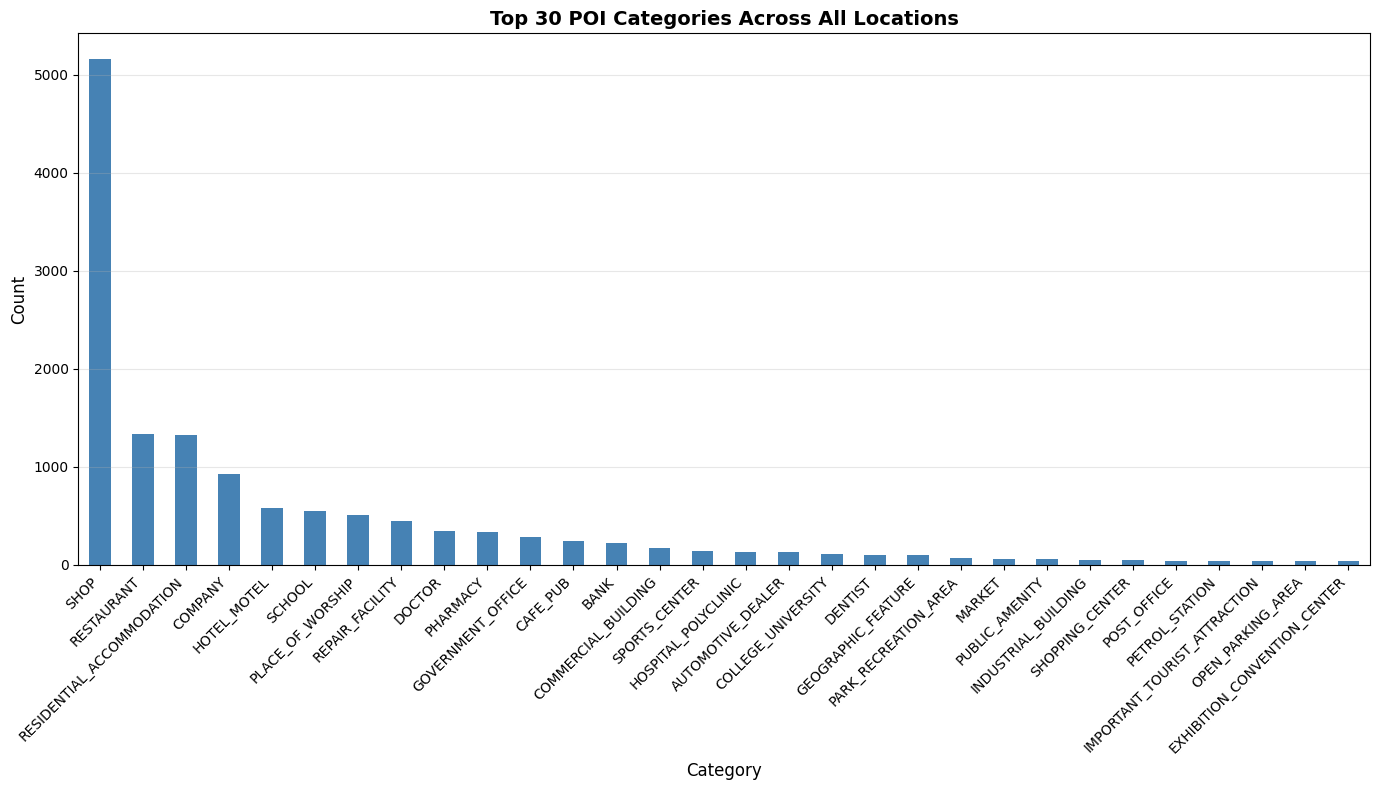

✓ Visualization complete - showing top 30 of 69 found categories


In [23]:
import matplotlib.pyplot as plt

# Create bar chart of top 30 category distribution
fig, ax = plt.subplots(figsize=(14, 8))
top_30 = non_zero_categories.head(30)
top_30.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 30 POI Categories Across All Locations', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"✓ Visualization complete - showing top 30 of {len(non_zero_categories)} found categories")